# Example: Pulling Market Data From Databento

This notebook teaches how to pull market data from
[Databento](https://databento.com/) while illustrating the difference between
using a **Python SDK** and making **raw API calls** (HTTP). It merges the
standalone exercises in the
[`databento/`](https://github.com/finm-32800/inclass_examples/tree/main/databento)
directory of the in-class examples repo into a single walkthrough:

1. **Historical SDK basics** — the simplest fetch: check cost, pull trades,
   convert to a DataFrame
2. **The raw HTTP API** — the same query with `curl`/`requests`, to see what
   the SDK abstracts away
3. **Symbology and schemas** — how Databento identifies instruments and
   organizes data
4. **Treasury futures market brief** — a small end-to-end application:
   two queries combined into four charts and a summary table

## Cost warning

Databento charges per query. The examples here keep costs negligible with
small `limit=` values, and the SDK sections call `metadata.get_cost` (free)
*before* fetching data, so you never spend money by accident. The market
brief in the final section downloads a few dollars' worth of data at most,
guards against anything larger, and caches the result to Parquet so
re-running the notebook is free.

## Dataset

All examples use **GLBX.MDP3** (CME Globex), which covers E-mini S&P 500
futures (ES), Treasury futures, and other CME products. Students have
subscriptions to this dataset.

## No live-data license

Databento has two modes of access, and **we only have the historical one**:

- **Historical** (`db.Historical()`) — archived data, billed per query. This
  is what everything in this notebook uses.
- **Live** (`db.Live()`) — real-time streaming over a persistent TCP
  connection, billed per subscription. **Our subscription does not include
  this.** An API key with historical access only will authenticate against
  the live gateway and then be rejected with
  `BentoError: A live data license is required to access GLBX.MDP3.` That
  message is about entitlement, not a bad key.

## Setup

Your Databento API key must be set as `DATABENTO_API_KEY` in the repo-root
`.env` file (see `.env.example`). We read it with the course-standard
`from settings import config` pattern and pass it to the client explicitly.

In [1]:
from pathlib import Path

from settings import config

DATA_DIR = Path(config("DATA_DIR"))
DATABENTO_API_KEY = config("DATABENTO_API_KEY")

import databento as db

client = db.Historical(key=DATABENTO_API_KEY)

## 1. Historical SDK Basics

The simplest workflow has four steps:

1. Create a `Historical` client
2. Check the estimated cost (a **free** metadata call)
3. Fetch the data only if the cost is acceptable
4. Convert to a pandas DataFrame

We define the query once as a dict so the cost check and the data pull are
guaranteed to describe the same request. `ES.FUT` with `stype_in="parent"`
means "all E-mini S&P 500 futures contracts" (more on symbology in
Section 3), and `limit=10` caps the number of records returned.

In [2]:
query = dict(
    dataset="GLBX.MDP3",
    symbols=["ES.FUT"],
    stype_in="parent",
    schema="trades",
    start="2024-08-01",
    end="2024-08-02",
    limit=10,
)

cost = client.metadata.get_cost(**query)
print(f"Estimated cost: ${cost:.4f}")

Estimated cost: $0.0000


The guard below is the habit to build: *always* check the cost before
fetching. This tiny query is free, so a non-zero estimate means the query
is not what we intended.

In [3]:
if cost > 0:
    raise RuntimeError(
        f"Estimated cost is ${cost:.4f}, expected $0.00 — "
        "review the query before fetching."
    )

data = client.timeseries.get_range(**query)

# Prices are automatically scaled to floats by the SDK
df_trades_sdk = data.to_df()
df_trades_sdk

,ts_event,rtype,publisher_id,instrument_id,action,side,depth,price,size,flags,ts_in_delta,sequence,symbol
ts_recv,,,,,,,,,,,,,
2024-08-01 00:00:00.079196344+00:00,2024-08-01 00:00:00.078950957+00:00,0,1,118,T,B,0,5587.75,5,0,14913,45877799,ESU4
2024-08-01 00:00:00.079236309+00:00,2024-08-01 00:00:00.078970329+00:00,0,1,118,T,B,0,5587.75,1,0,14376,45877800,ESU4
2024-08-01 00:00:00.079349483+00:00,2024-08-01 00:00:00.079156215+00:00,0,1,118,T,B,0,5587.75,1,0,14712,45877801,ESU4
2024-08-01 00:00:00.079868759+00:00,2024-08-01 00:00:00.079685131+00:00,0,1,118,T,B,0,5587.75,1,0,14558,45877816,ESU4
2024-08-01 00:00:00.094556955+00:00,2024-08-01 00:00:00.094305073+00:00,0,1,118,T,A,0,5587.75,1,0,15096,45877890,ESU4
2024-08-01 00:00:00.123901714+00:00,2024-08-01 00:00:00.123669805+00:00,0,1,118,T,A,0,5587.75,1,0,14589,45877906,ESU4
2024-08-01 00:00:00.211571140+00:00,2024-08-01 00:00:00.211326531+00:00,0,1,118,T,A,0,5587.75,2,0,14989,45877936,ESU4
2024-08-01 00:00:00.211785774+00:00,2024-08-01 00:00:00.211514531+00:00,0,1,118,T,A,0,5587.75,7,0,14566,45877938,ESU4
2024-08-01 00:00:00.291190144+00:00,2024-08-01 00:00:00.290962393+00:00,0,1,118,T,A,0,5587.50,1,0,14715,45877987,ESU4


Each row is one trade: the index is the exchange receive timestamp
(`ts_recv`), `price` is already in dollars, `size` is the number of
contracts, and `side` is the aggressor side (`B` = buyer initiated,
`A` = seller initiated). Notice the SDK also mapped the numeric
`instrument_id` back to the human-readable contract ticker in `symbol`.

## 2. The Raw HTTP API

The SDK is a thin layer over a REST API. The same query as Section 1 can be
made with `curl`:

```bash
# HTTP Basic Auth: API key is the username, password is empty.
# The -u flag sets the Authorization header: base64(key:)
curl -s \
  -u "${DATABENTO_API_KEY}:" \
  -X POST \
  "https://hist.databento.com/v0/timeseries.get_range" \
  -d "dataset=GLBX.MDP3" \
  -d "symbols=ES.FUT" \
  -d "stype_in=parent" \
  -d "schema=trades" \
  -d "start=2024-08-01" \
  -d "end=2024-08-02" \
  -d "encoding=json" \
  -d "limit=10"
```

### curl flags explained

| Flag | Meaning |
|------|---------|
| `-s` | **Silent mode.** Suppresses the progress bar so you only see the response body. |
| `-u "${DATABENTO_API_KEY}:"` | **HTTP Basic Auth.** The API key is the username; the trailing colon means the password is empty. curl base64-encodes `key:` and sends `Authorization: Basic <encoded>`. |
| `-X POST` | **HTTP method.** Specifies the request method (see below). |
| `-d "key=value"` | **Data / form field.** Sends a key-value pair in the request body as `application/x-www-form-urlencoded`. Each `-d` flag adds another field. When `-d` is present, curl implies `-X POST`, so the explicit flag is technically redundant but makes intent clear. |

### HTTP methods

Every HTTP request includes a **method** (or "verb") that tells the server
what kind of operation you intend:

| Method | Purpose | Body? | Example |
|--------|---------|-------|---------|
| `GET` | **Read** a resource. What your browser sends when you visit a URL. Parameters go in the query string (`?key=value`). | No | `GET /v0/metadata.list_datasets` |
| `POST` | **Send data** to the server to create or query something. Parameters go in the request body. | Yes | `POST /v0/timeseries.get_range` |
| `PUT` | **Replace** a resource entirely with new data. | Yes | `PUT /users/42` |
| `PATCH` | **Partially update** a resource (only the fields you send). | Yes | `PATCH /users/42` |
| `DELETE` | **Remove** a resource. | Rarely | `DELETE /users/42` |

**Why POST here?** Databento's query has many parameters (dataset, symbols,
date range, schema, ...). Packing all of that into a URL query string would
be unwieldy, so the API uses POST with form-encoded body fields. This is a
common pattern for "read" endpoints that take complex inputs.

### The same request from Python

`requests.post` is the Python equivalent of the curl command. We run the
same query (with `limit=5`) and look at the raw response before any SDK
processing.

In [4]:
import json

import requests

response = requests.post(
    "https://hist.databento.com/v0/timeseries.get_range",
    auth=(DATABENTO_API_KEY, ""),  # HTTP Basic Auth: key as username, empty password
    data={
        "dataset": "GLBX.MDP3",
        "symbols": "ES.FUT",
        "stype_in": "parent",
        "schema": "trades",
        "start": "2024-08-01",
        "end": "2024-08-02",
        "encoding": "json",
        "limit": 5,
    },
)
response.raise_for_status()

# The response is newline-delimited JSON (one record per line)
lines = response.text.strip().split("\n")
print(json.dumps(json.loads(lines[0]), indent=2))

{
  "ts_recv": "1722470400079196344",
  "hd": {
    "ts_event": "1722470400078950957",
    "rtype": 0,
    "publisher_id": 1,
    "instrument_id": 118
  },
  "action": "T",
  "side": "B",
  "depth": 0,
  "price": "5587750000000",
  "size": 5,
  "flags": 0,
  "ts_in_delta": 14913,
  "sequence": 45877799
}


### Reading the raw record

| Field | Example | Meaning |
|-------|---------|---------|
| `ts_recv` | `1722470400079196344` | Exchange receive timestamp (nanoseconds since Unix epoch) |
| `hd.ts_event` | `1722470400078950957` | Matching-engine event timestamp (ns) |
| `hd.rtype` | `0` | Record type: `0` = MBP-0 / trade |
| `hd.publisher_id` | `1` | Venue ID (`1` = CME) |
| `hd.instrument_id` | `118` | Numeric instrument ID for this contract |
| `action` | `"T"` | Message action: `T` = Trade |
| `side` | `"B"` / `"A"` | Aggressor side: `B` = buyer initiated, `A` = seller initiated |
| `price` | `5587750000000` | **Fixed-point integer** — multiply by 1e-9 → **$5,587.75** |
| `size` | `5` | Number of contracts traded |
| `ts_in_delta` | `14913` | Capture latency: `ts_recv - ts_event` in nanoseconds (~15 μs) |
| `sequence` | `45877799` | Exchange sequence number (detect gaps / ordering) |

Two gotchas in the raw JSON that the SDK hides from you:

1. **64-bit integers are encoded as strings** (`"5587750000000"`), because
   JSON numbers are doubles and would lose precision. Cast with `int()`
   first.
2. **`ts_event` lives in the record header** (`hd`), not at the top level.
   Only `ts_recv` is top-level.

Databento stores prices as fixed-point integers to avoid floating-point
rounding: divide by 1e9 to get dollars.

In [5]:
for line in lines:
    record = json.loads(line)
    raw_price = int(record["price"])  # arrives as a string!
    actual_price = raw_price * 1e-9  # fixed-point -> dollars
    ts_event = record["hd"]["ts_event"]
    print(f"ts={ts_event}  price={raw_price} (raw) -> ${actual_price:.2f}")

ts=1722470400078950957  price=5587750000000 (raw) -> $5587.75
ts=1722470400078970329  price=5587750000000 (raw) -> $5587.75
ts=1722470400079156215  price=5587750000000 (raw) -> $5587.75
ts=1722470400079685131  price=5587750000000 (raw) -> $5587.75
ts=1722470400094305073  price=5587750000000 (raw) -> $5587.75


### SDK vs API — what's the difference?

| | SDK (`databento` package) | Raw API (curl / `requests`) |
|---|---|---|
| **Auth** | Pass key to constructor or set env var | HTTP Basic Auth |
| **Data format** | Auto-decoded to DataFrames | Raw JSON or binary DBN |
| **Price scaling** | Automatic (human-readable floats) | Raw fixed-point integers (multiply by 1e-9) |
| **Integer encoding** | Native Python `int` | JSON encodes 64-bit ints as *strings* |
| **Error handling** | Python exceptions | HTTP status codes |

You'll normally use the SDK — but when it misbehaves, knowing the protocol
underneath is what lets you debug it.

## 3. Symbology: Four Ways to Name an Instrument

The same underlying product (the E-mini S&P 500 future) can be referenced
in four different ways, depending on your use case:

| Type | Example | Use case |
|------|---------|----------|
| `raw_symbol` | `ESH4`, `ESU4` | Specific contract by exchange ticker |
| `parent` | `ES.FUT` | All contracts for a product (e.g., all ES futures) |
| `continuous` | `ES.c.0` | Front-month (rolling), no manual roll management |
| `instrument_id` | `3403` | Numeric ID from the exchange, most compact |

### Reading a `raw_symbol`

CME futures tickers follow the format **Root + Month Code + Year Digit**.
For example, `ESU4` = **ES** (E-mini S&P 500) + **U** (September) + **4**
(2024).

| F | G | H | J | K | M | N | Q | U | V | X | Z |
|---|---|---|---|---|---|---|---|---|---|---|---|
| Jan | Feb | Mar | Apr | May | Jun | Jul | Aug | Sep | Oct | Nov | Dec |

ES futures trade on a quarterly cycle, so you'll only see **H** (Mar),
**M** (Jun), **U** (Sep), **Z** (Dec).

### Reading a `parent` symbol

Format: **Root.AssetClass**. `ES.FUT` = all E-mini S&P 500 **futures**
(outrights and spreads); `ES.OPT` = all E-mini S&P 500 **options**.

### Reading a `continuous` symbol

Format: **Root.Rule.Rank**, where **Rule** selects the roll method
(`c` = calendar / nearest expiry, `v` = volume, `n` = open interest) and
**Rank** selects which contract (`0` = front month, `1` = second nearest,
...). Examples: `ES.c.0` = front-month ES by expiry date; `ES.v.0` =
most-traded ES contract by volume.

### `instrument_id`

Numeric IDs assigned by the exchange. Compact but less portable — some
venues remap IDs daily.

Let's see `parent` and `raw_symbol` side by side. First, `ES.FUT` returns
trades from **all** active ES contracts:

In [6]:
data_parent = client.timeseries.get_range(
    dataset="GLBX.MDP3",
    symbols=["ES.FUT"],
    stype_in="parent",
    schema="trades",
    start="2024-08-01",
    end="2024-08-02",
    limit=5,
)
df_parent = data_parent.to_df()
df_parent[["symbol", "price", "size"]]

,symbol,price,size
ts_recv,,,
2024-08-01 00:00:00.079196344+00:00,ESU4,5587.75,5
2024-08-01 00:00:00.079236309+00:00,ESU4,5587.75,1
2024-08-01 00:00:00.079349483+00:00,ESU4,5587.75,1
2024-08-01 00:00:00.079868759+00:00,ESU4,5587.75,1
2024-08-01 00:00:00.094556955+00:00,ESU4,5587.75,1


Then `ESU4` with `stype_in="raw_symbol"` returns trades from **one**
specific contract (September 2024):

In [7]:
data_raw = client.timeseries.get_range(
    dataset="GLBX.MDP3",
    symbols=["ESU4"],
    stype_in="raw_symbol",
    schema="trades",
    start="2024-08-01",
    end="2024-08-02",
    limit=5,
)
df_raw = data_raw.to_df()
df_raw[["symbol", "price", "size"]]

,symbol,price,size
ts_recv,,,
2024-08-01 00:00:00.079196344+00:00,ESU4,5587.75,5
2024-08-01 00:00:00.079236309+00:00,ESU4,5587.75,1
2024-08-01 00:00:00.079349483+00:00,ESU4,5587.75,1
2024-08-01 00:00:00.079868759+00:00,ESU4,5587.75,1
2024-08-01 00:00:00.094556955+00:00,ESU4,5587.75,1


Rules of thumb:

- `parent` is the most convenient for "all ES futures" without knowing
  specific tickers
- `continuous` is ideal for backtesting — it handles contract rolls
  automatically
- `raw_symbol` is what you'd use on a trading desk (a specific contract)

## 4. Schemas: How Granular Is the Data?

A **schema** is the shape of the records you get back. They form a
hierarchy from full order-book detail down to daily bars:

```text
Most granular                              Least granular
     |                                          |
     v                                          v
    mbo  →  mbp-10  →  mbp-1  →  trades  →  ohlcv-1s  →  ohlcv-1m  →  ohlcv-1d
 (L3 book)  (L2 depth)  (L1 top)  (last sale)  (1s bars)   (1m bars)   (daily)
```

More granular = more data = higher cost. **Use the coarsest schema that
meets your needs.** Here we fetch the same 30-minute window at three levels
of granularity.

In [8]:
PARAMS = dict(
    dataset="GLBX.MDP3",
    symbols=["ES.FUT"],
    stype_in="parent",
    start="2024-08-01T14:30:00",  # 30 min window during market hours
    end="2024-08-01T15:00:00",
    limit=10,
)

df_schema_trades = client.timeseries.get_range(schema="trades", **PARAMS).to_df()
df_schema_trades[["symbol", "price", "size"]]

,symbol,price,size
ts_recv,,,
2024-08-01 14:30:00.002504512+00:00,ESU4,5550.5,1
2024-08-01 14:30:00.009743452+00:00,ESU4,5550.5,2
2024-08-01 14:30:00.009937551+00:00,ESU4,5550.5,5
2024-08-01 14:30:00.010159425+00:00,ESU4,5550.5,24
2024-08-01 14:30:00.010519155+00:00,ESU4,5550.5,1
2024-08-01 14:30:00.010560969+00:00,ESU4,5550.5,1
2024-08-01 14:30:00.010803036+00:00,ESU4,5550.5,4
2024-08-01 14:30:00.010950754+00:00,ESU4,5550.5,2
2024-08-01 14:30:00.011308309+00:00,ESU4,5550.5,5


The `trades` schema returned 10 individual ticks covering barely a second
of trading. One-second bars summarize each second as an
open/high/low/close/volume row:

In [9]:
df_schema_1s = client.timeseries.get_range(schema="ohlcv-1s", **PARAMS).to_df()
df_schema_1s[["symbol", "open", "high", "low", "close", "volume"]]

,symbol,open,high,low,close,volume
ts_event,,,,,,
2024-08-01 14:30:00+00:00,ESU4,5550.50,5550.75,5549.75,5550.00,430
2024-08-01 14:30:01+00:00,ESU4,5550.25,5550.25,5549.25,5549.75,262
2024-08-01 14:30:02+00:00,ESU4,5549.50,5549.75,5549.00,5549.25,293
2024-08-01 14:30:03+00:00,ESU4,5549.50,5550.25,5549.25,5550.25,296
2024-08-01 14:30:04+00:00,ESU4,5550.00,5551.00,5549.75,5551.00,285
2024-08-01 14:30:05+00:00,ESU4,5550.75,5551.50,5550.75,5551.50,187
2024-08-01 14:30:06+00:00,ESU4,5551.50,5552.00,5551.25,5551.75,170
2024-08-01 14:30:07+00:00,ESU4,5551.75,5552.25,5551.50,5552.00,118
2024-08-01 14:30:08+00:00,ESU4,5551.75,5552.00,5551.50,5551.50,276


And one-minute bars cover the same window in far fewer rows:

In [10]:
df_schema_1m = client.timeseries.get_range(schema="ohlcv-1m", **PARAMS).to_df()
df_schema_1m[["symbol", "open", "high", "low", "close", "volume"]]

,symbol,open,high,low,close,volume
ts_event,,,,,,
2024-08-01 14:30:00+00:00,ESU4,5550.50,5554.50,5549.00,5553.75,7585
2024-08-01 14:30:00+00:00,ESU4-ESZ4,61.15,61.15,61.15,61.15,1
2024-08-01 14:31:00+00:00,ESU4-ESZ4,61.05,61.05,61.05,61.05,1
2024-08-01 14:31:00+00:00,ESU4,5553.75,5554.50,5546.75,5548.00,7720
2024-08-01 14:32:00+00:00,ESZ4-ESH5,56.60,56.60,56.60,56.60,5
2024-08-01 14:32:00+00:00,ESH5,5665.75,5665.75,5665.75,5665.75,1
2024-08-01 14:32:00+00:00,ESU4-ESZ4,61.05,61.05,61.05,61.05,1
2024-08-01 14:32:00+00:00,ESZ4,5608.00,5608.00,5606.00,5606.00,3
2024-08-01 14:32:00+00:00,ESU4,5548.00,5549.75,5543.50,5544.00,9799


For most research, start with `ohlcv-1m` or `trades`; only reach for
`mbo`/`mbp-10` if you actually need order-book depth.

## 5. Application: A Treasury Futures Market Brief

Now a small end-to-end example: a market brief for Treasury futures across
the yield curve, combining two Databento queries into four charts and a
summary table.

| Symbol | Product | Tenor |
|--------|---------|-------|
| ZT | 2-Year T-Note | 2Y |
| ZF | 5-Year T-Note | 5Y |
| ZN | 10-Year T-Note | 10Y |
| TN | Ultra 10-Year T-Note | Ultra 10Y |
| ZB | 30-Year T-Bond | 30Y |

We make two queries:

1. **Daily OHLCV bars** using *continuous* contracts — clean price series
   that roll automatically
2. **Statistics** (open interest) using *parent* symbology — aggregate
   activity across all expirations

### Why `.v.0` and not `.c.0`?

We use `ZN.v.0` (roll by **volume**), not `ZN.c.0` (roll by **calendar**).
The distinction matters a lot for Treasury futures: `.c.0` rolls only when
the front contract expires, and ZT/ZF stay listed through the end of their
delivery month — so `.c.0` keeps pointing at a contract that everyone has
already rolled out of, and daily volume collapses to double digits for
weeks at a time. `.v.0` rolls when volume migrates to the next expiration,
which is what a market brief actually wants.

In [11]:
import numpy as np
import pandas as pd

DATASET = "GLBX.MDP3"

PRODUCTS = ["ZT", "ZF", "ZN", "TN", "ZB"]
TENORS = {"ZT": "2Y", "ZF": "5Y", "ZN": "10Y", "TN": "Ultra 10Y", "ZB": "30Y"}
COLORS = {
    "ZT": "#1f77b4",
    "ZF": "#ff7f0e",
    "ZN": "#2ca02c",
    "TN": "#d62728",
    "ZB": "#9467bd",
}

# Continuous front-month symbols for daily OHLCV (roll by volume)
OHLCV_SYMBOLS = ["ZT.v.0", "ZF.v.0", "ZN.v.0", "TN.v.0", "ZB.v.0"]

# Parent symbols for statistics (open interest across all expirations)
STATS_SYMBOLS = ["ZT.FUT", "ZF.FUT", "ZN.FUT", "TN.FUT", "ZB.FUT"]

START = "2024-07-01"
END = "2025-01-01"

# Parent symbology x statistics schema is very large over long windows, so
# the statistics query only covers the last few days of the window.
STATS_START = (pd.Timestamp(END) - pd.Timedelta(days=5)).strftime("%Y-%m-%d")

### Fetch once, cache to Parquet

This is the only section of the notebook that downloads a meaningful amount
of data (a few dollars at most). To avoid re-paying every time the notebook
runs, we cache both query results as Parquet files under the repo's data
directory and **skip the API entirely when the cache exists**. Delete the
files to force a fresh download.

In [12]:
DATABENTO_DATA_DIR = DATA_DIR / "databento"
DATABENTO_DATA_DIR.mkdir(parents=True, exist_ok=True)

ohlcv_path = DATABENTO_DATA_DIR / "ohlcv_daily.parquet"
oi_path = DATABENTO_DATA_DIR / "open_interest.parquet"

use_cache = ohlcv_path.exists() and oi_path.exists()
print(f"Using cached Parquet files: {use_cache}")

Using cached Parquet files: True


On a fresh fetch we first estimate the cost of both queries (free metadata
calls) and stop if the total looks wrong — the same habit as Section 1,
with a higher tolerance because this data genuinely costs a little money.

In [13]:
if not use_cache:
    ohlcv_cost = client.metadata.get_cost(
        dataset=DATASET,
        symbols=OHLCV_SYMBOLS,
        stype_in="continuous",
        schema="ohlcv-1d",
        start=START,
        end=END,
    )
    stats_cost = client.metadata.get_cost(
        dataset=DATASET,
        symbols=STATS_SYMBOLS,
        stype_in="parent",
        schema="statistics",
        start=STATS_START,
        end=END,
    )
    total_cost = ohlcv_cost + stats_cost
    print(f"OHLCV daily:  ${ohlcv_cost:.4f}")
    print(f"Statistics:   ${stats_cost:.4f}")
    print(f"Total:        ${total_cost:.4f}")
    if total_cost > 5.0:
        raise RuntimeError(
            f"Total cost ${total_cost:.4f} exceeds $5.00 — review before proceeding."
        )

    ohlcv_data = client.timeseries.get_range(
        dataset=DATASET,
        symbols=OHLCV_SYMBOLS,
        stype_in="continuous",
        schema="ohlcv-1d",
        start=START,
        end=END,
    )
    ohlcv_data.to_df().to_parquet(ohlcv_path)
    print(f"Saved {ohlcv_path.name}")

### Open interest via the statistics schema — and a data-cleaning lesson

The `statistics` schema carries exchange-published figures (settlement
prices, volume summaries, open interest, ...) distinguished by `stat_type`.
Open interest is `stat_type == 9`
([docs](https://databento.com/docs/schemas-and-data-formats/whats-in-a-schema/statistics)).
Getting from raw statistics records to a clean daily series takes three
steps:

1. **Filter to `stat_type == 9`** — the schema mixes many statistic types.
2. **Drop calendar spreads** (symbols like `ZNH5-ZNM5`) — we want outright
   contracts only.
3. **Deduplicate before aggregating.** CME publishes open interest for a
   given trade date **twice**: a preliminary figure shortly after the close,
   then a final figure the next morning. Both arrive as separate records
   with the *same* `ts_ref` (the trade date the statistic describes).
   Summing them naively double-counts — the 10-Year would show ~9.1M
   contracts when the true figure is ~4.5M. The fix: group by
   (contract, `ts_ref`) and keep the record that arrived last, which is the
   final revision.

In [14]:
if not use_cache:
    stats_data = client.timeseries.get_range(
        dataset=DATASET,
        symbols=STATS_SYMBOLS,
        stype_in="parent",
        schema="statistics",
        start=STATS_START,
        end=END,
    )
    df_stats = stats_data.to_df()
    print(f"Raw statistics records: {len(df_stats)}")

    # Step 1: open interest only
    df_oi_raw = df_stats[df_stats["stat_type"] == 9].copy()

    # Step 2: outright contracts only
    df_oi_raw = df_oi_raw[~df_oi_raw["symbol"].str.contains("-")]

    # Step 3: keep the final revision per (contract, trade date)
    df_oi_raw = df_oi_raw.sort_index()  # ts_recv ascending
    df_oi_raw = df_oi_raw.groupby(["symbol", "ts_ref"], as_index=False).last()

    # The statistic describes ts_ref (the trade date), not when we received it
    df_oi_raw["date"] = (
        pd.to_datetime(df_oi_raw["ts_ref"]).dt.normalize().dt.tz_localize(None)
    )

    # Extract product root ("ZNH5" -> "ZN") and aggregate across expirations
    df_oi_raw["product"] = df_oi_raw["symbol"].str.extract(r"^([A-Z]{2})")
    df_oi_agg = (
        df_oi_raw.groupby(["date", "product"])["quantity"].sum().reset_index()
    )
    df_oi_agg.columns = ["date", "product", "open_interest"]
    df_oi_agg.to_parquet(oi_path, index=False)
    print(f"Saved {oi_path.name}")

From here on everything reads from the local Parquet files, so the analysis
below runs identically whether the data was just fetched or loaded from
cache.

In [15]:
df_ohlcv = pd.read_parquet(ohlcv_path)
df_oi = pd.read_parquet(oi_path)

# Extract product root from symbol (e.g., "ZN.v.0" -> "ZN")
df_ohlcv["product"] = df_ohlcv["symbol"].str.split(".").str[0]
df_ohlcv["date"] = pd.to_datetime(df_ohlcv.index)

# Pivot to wide format (date x product), in curve order
close = df_ohlcv.pivot_table(index="date", columns="product", values="close")
volume = df_ohlcv.pivot_table(index="date", columns="product", values="volume")
close = close[[p for p in PRODUCTS if p in close.columns]]
volume = volume[[p for p in PRODUCTS if p in volume.columns]]

close.tail()

product,ZT,ZF,ZN,TN,ZB
date,,,,,
2024-12-26 00:00:00+00:00,102.667969,106.117188,108.640625,111.250000,113.84375
2024-12-27 00:00:00+00:00,102.667969,106.015625,108.375000,110.859375,113.15625
2024-12-29 00:00:00+00:00,102.671875,106.015625,108.375000,110.828125,113.09375
2024-12-30 00:00:00+00:00,102.820312,106.421875,109.015625,111.656250,114.28125
2024-12-31 00:00:00+00:00,102.816406,106.328125,108.765625,111.296875,113.75000


### Chart 1: Indexed price performance

Normalizing every series to 100 at the start of the window makes the
relative moves across tenors comparable even though the contracts trade at
very different price levels.

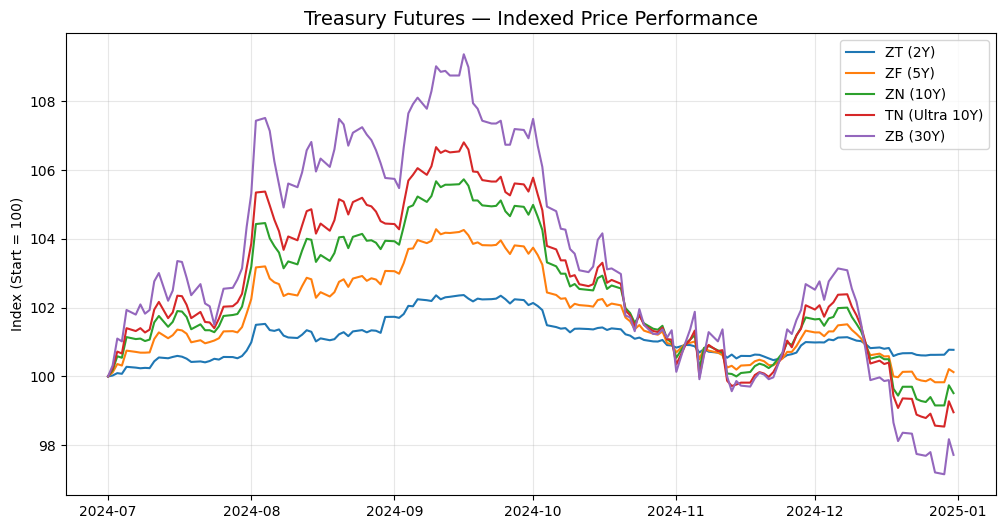

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
indexed = close / close.iloc[0] * 100
for prod in indexed.columns:
    ax.plot(
        indexed.index,
        indexed[prod],
        label=f"{prod} ({TENORS[prod]})",
        color=COLORS[prod],
        linewidth=1.5,
    )
ax.set_title("Treasury Futures — Indexed Price Performance", fontsize=14)
ax.set_ylabel("Index (Start = 100)")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.show()

### Chart 2: Curve spreads

Long-tenor minus short-tenor price spreads (10s-2s, 30s-5s) as a rough
steepening/flattening gauge. These are raw price spreads, not
DV01-weighted, so read them as direction rather than magnitude.

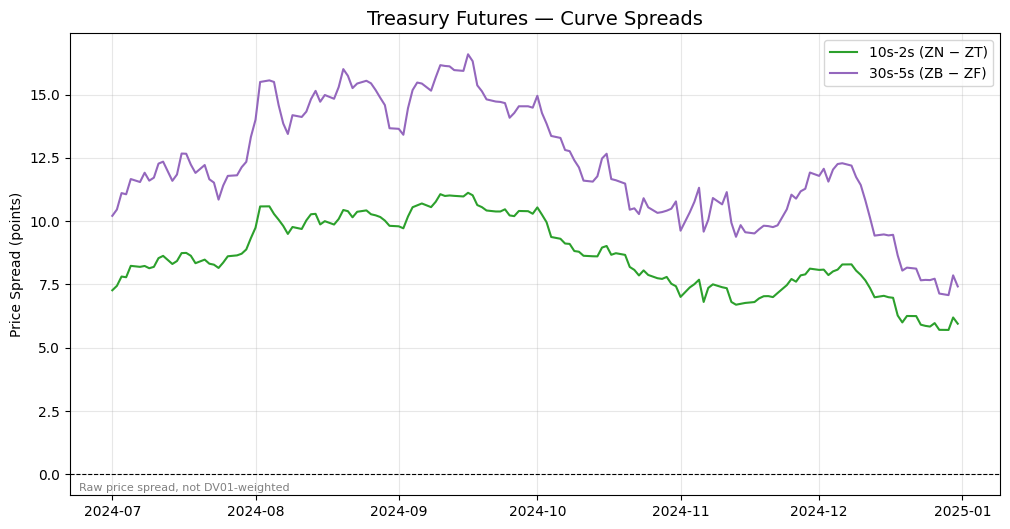

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))
spread_10s2s = close["ZN"] - close["ZT"]
ax.plot(
    spread_10s2s.index,
    spread_10s2s,
    label="10s-2s (ZN − ZT)",
    color="#2ca02c",
    linewidth=1.5,
)
spread_30s5s = close["ZB"] - close["ZF"]
ax.plot(
    spread_30s5s.index,
    spread_30s5s,
    label="30s-5s (ZB − ZF)",
    color="#9467bd",
    linewidth=1.5,
)
ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Treasury Futures — Curve Spreads", fontsize=14)
ax.set_ylabel("Price Spread (points)")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
ax.text(
    0.01,
    0.01,
    "Raw price spread, not DV01-weighted",
    transform=ax.transAxes,
    fontsize=8,
    color="gray",
)
plt.show()

### Chart 3: Volume and open interest

Average daily volume (from the OHLCV query) next to the latest open
interest (from the statistics query) shows where activity concentrates on
the curve — the 10-Year dominates both measures.

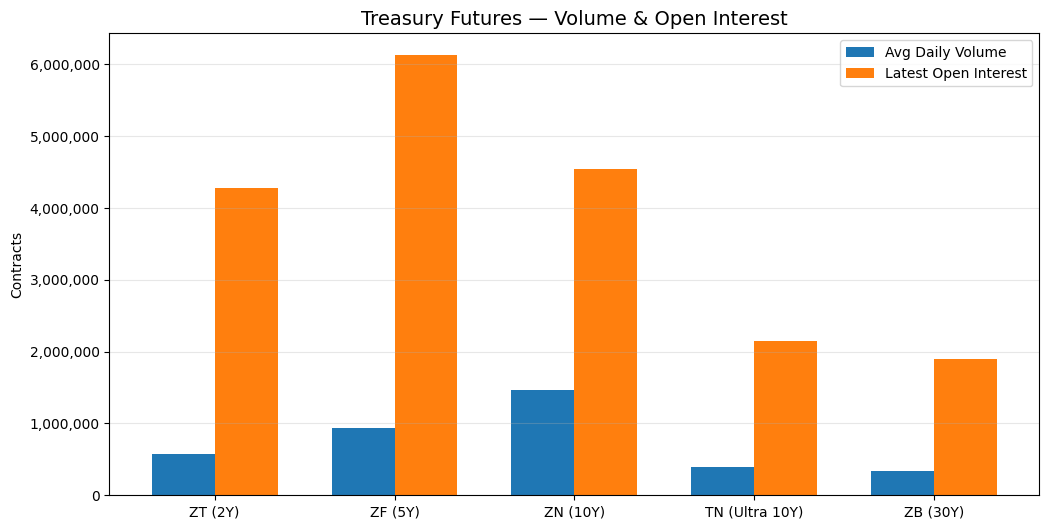

In [18]:
avg_volume = volume.mean()
latest_oi = df_oi.sort_values("date").groupby("product").last()["open_interest"]

bar_products = [p for p in PRODUCTS if p in avg_volume.index]
bar_labels = [f"{p} ({TENORS[p]})" for p in bar_products]
vol_vals = [avg_volume[p] for p in bar_products]
oi_vals = [latest_oi.get(p, 0) for p in bar_products]

x = np.arange(len(bar_products))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width / 2, vol_vals, width, label="Avg Daily Volume", color="#1f77b4")
ax.bar(x + width / 2, oi_vals, width, label="Latest Open Interest", color="#ff7f0e")
ax.set_title("Treasury Futures — Volume & Open Interest", fontsize=14)
ax.set_ylabel("Contracts")
ax.set_xticks(x)
ax.set_xticklabels(bar_labels)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
plt.show()

### Chart 4: Rolling volatility

A 20-day rolling standard deviation of daily returns, annualized. Note how
volatility rises with tenor — the 30-Year moves far more than the 2-Year.

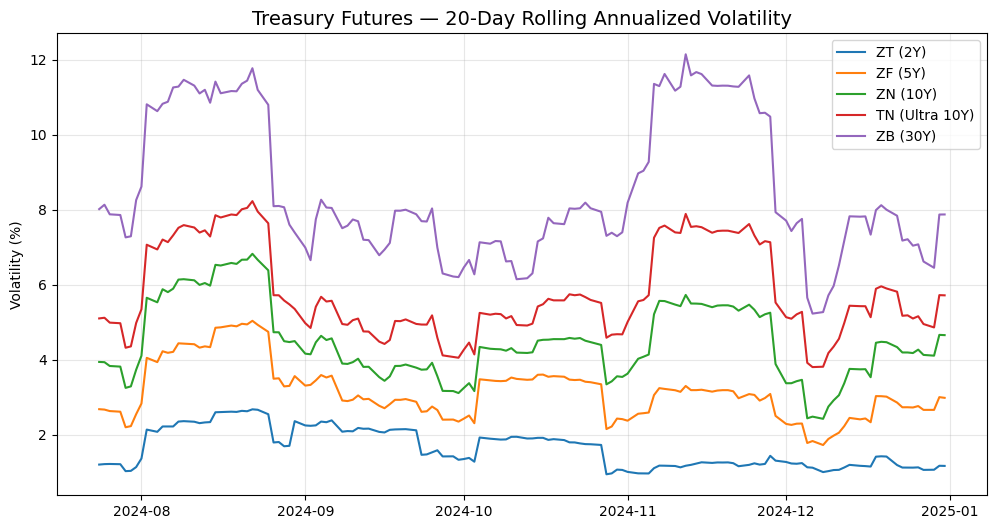

In [19]:
returns = close.pct_change(fill_method=None)
rolling_vol = returns.rolling(20).std() * np.sqrt(252) * 100

fig, ax = plt.subplots(figsize=(12, 6))
for prod in rolling_vol.columns:
    ax.plot(
        rolling_vol.index,
        rolling_vol[prod],
        label=f"{prod} ({TENORS[prod]})",
        color=COLORS[prod],
        linewidth=1.5,
    )
ax.set_title("Treasury Futures — 20-Day Rolling Annualized Volatility", fontsize=14)
ax.set_ylabel("Volatility (%)")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.show()

### Market snapshot table

In [20]:
rows = []
for prod in PRODUCTS:
    if prod not in close.columns:
        continue
    series = close[prod].dropna()
    last_price = series.iloc[-1]
    daily_chg = series.iloc[-1] - series.iloc[-2] if len(series) >= 2 else np.nan
    five_day_chg = series.iloc[-1] - series.iloc[-6] if len(series) >= 6 else np.nan
    avg_vol_20d = volume[prod].tail(20).mean() if prod in volume.columns else np.nan
    oi = latest_oi.get(prod, np.nan)
    rows.append(
        {
            "Product": prod,
            "Tenor": TENORS[prod],
            "Last Price": f"{last_price:.3f}",
            "Daily Chg": f"{daily_chg:+.3f}",
            "5-Day Chg": f"{five_day_chg:+.3f}",
            "20D Avg Volume": f"{avg_vol_20d:,.0f}",
            "Open Interest": f"{oi:,.0f}",
        }
    )

df_table = pd.DataFrame(rows)
df_table

,Product,Tenor,Last Price,Daily Chg,5-Day Chg,20D Avg Volume,Open Interest
0,ZT,2Y,102.816,-0.004,+0.168,"397,808","4,275,521"
1,ZF,5Y,106.328,-0.094,+0.281,"688,089","6,127,196"
2,ZN,10Y,108.766,-0.250,+0.281,"1,010,347","4,540,185"
3,TN,Ultra 10Y,111.297,-0.359,+0.188,"318,219","2,147,557"
4,ZB,30Y,113.750,-0.531,+0.031,"268,478","1,903,499"


## Where to Go From Here

The standalone versions of these examples (runnable scripts with their own
READMEs, including the pure-`curl` version of Section 2) live in the
[`databento/`](https://github.com/finm-32800/inclass_examples/tree/main/databento)
directory of the in-class examples repo:

- [`01_historical_sdk`](https://github.com/finm-32800/inclass_examples/tree/main/databento/01_historical_sdk)
- [`02_historical_api`](https://github.com/finm-32800/inclass_examples/tree/main/databento/02_historical_api)
- [`03_schemas_and_symbology`](https://github.com/finm-32800/inclass_examples/tree/main/databento/03_schemas_and_symbology)
- [`04_treasury_futures_brief`](https://github.com/finm-32800/inclass_examples/tree/main/databento/04_treasury_futures_brief)

Exercises to try:

- In Section 3, try `NQ.FUT` (Nasdaq futures) as the parent symbol
- In Section 4, add `ohlcv-1h` as a fourth schema level
- In Section 5, add `UB.v.0` (Ultra T-Bond) as a sixth product, or switch
  the continuous rule from `.v.0` to `.c.0` and watch what happens to ZT
  and ZF volume
- Compute DV01-weighted curve spreads instead of raw price spreads

Further reading:

- [Databento documentation](https://databento.com/docs/)
- [Schemas and data formats](https://databento.com/docs/schemas-and-data-formats)
- [Symbology](https://databento.com/docs/standards-and-conventions/symbology)